In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import statsmodels as stat
import datetime as dt

import missingno as msno

In [2]:
data_2016=pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [3]:
data_2016

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57


In [4]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

# Définition des variables:
Variables

OSEBuildingID : L'ID du batiment

DataYear : Année de consommation

BuildingType : Type de Building (Résidence ou pas)

PrimaryPropertyType : Type de propriété (Hotel, Ecole...)

PropertyName : Nom du bâtiment

Address : L'adresse du bâtiment

City : La ville ou est situé le bâtiment

State : L'état ou est situé le bâtiment

ZipCode : Code postal (peut etre différent même dans un même état)

TaxParcelIdentificationNumber : Numero identification (fiscale)

CouncilDistrictCode : code du district du conseil de la ville de Seattle

Neighborhood : Quartier

Latitude : La latitude
Longitude : La longitude

YearBuilt : Date de création ou de rénovation

NumberofBuildings : Nombre de buildings dans la propriété

NumberofFloors : Nombre d'étages

PropertyGFATotal : Surface brute de plancher totale du bâtiment et du parking

PropertyGFAParking : Espace brute de tous les types de stationnement

PropertyGFABuilding(s) : Surface brute du bâtiment

ListOfAllPropertyUseTypes : Types d'utilisation de la propriété

LargestPropertyUseType : Type d'utilisation principale de la propriété

LargestPropertyUseTypeGFA : Surface brute de plancher (Utilisation principale)

SecondLargestPropertyUseType : Type d'utilisation secondaire de la propriété

SecondLargestPropertyUseTypeGFA: Surface brute de plancher (Utilisation secondaire)

ThirdLargestPropertyUseType : Type d'utilisation tertiaire de la propriété

ThirdLargestPropertyUseTypeGFA : Surface brute de plancher (Utilisation tertiaire)

YearsENERGYSTARCertified : Année auquel la propriété a recu la certification ENERGYSTAR

ENERGYSTARScore : Score (de 1 a 100) qui calcule la performance énergétique d'un bien immobilier

SiteEUI(kBtu/sf) : Energie annuelle consommée d'un bien immobilier / Surface brute de plancher

SiteEUIWN(kBtu/sf) : SiteEUI(kBtu/sf) normalisée en fonctions des conditions météologiques

SourceEUI(kBtu/sf) : Energie annuelle consommée d'un bien immobilier (y compris les pertes) / Surface brute de plancher

SourceEUIWN(kBtu/sf) : SourceEUI(kBtu/sf) normalisée en fonctions des conditions météologiques

SiteEnergyUse(kBtu) : Quantité annuelle d'énergie consommée, toutes sources d'énergie confondues

SiteEnergyUseWN(kBtu) : SiteEnergyUse(kBtu) normalisée en fonctions des conditions météologiques

SteamUse(kBtu) : Quantité annuelle de vapeur urbaine consommée

Electricity(kWh) : Quantité annuelle d'électricité consommée

Electricity(kBtu) : Electricity mais en British thermal units (kBtu)

NaturalGas(therms) : Quantité annuelle de gaz naturel consommée (therms)

NaturalGas(kBtu) : NaturalGas mais en British thermal units (kBtu).

DefaultData : La propriété utilisait des données par défaut pour au moins une caractéristique de propriété. 

Comments : Commentaires d’un propriétaire ou d’un agent d’immeuble pour fournir un contexte à la consommation d’énergie du 
                        bâtiment. 

ComplianceStatus indique si une propriété a satisfait aux exigences d’analyse comparative énergétique pour l’année de   
                                     déclaration en cours.
                                     
Outlier :Si une propriété est une valeur aberrante élevée ou faible (O/N)

TotalGHGEmissions : Quantité totale d'émissions de (dioxyde de carbone + le méthane + l'oxyde nitreux)

GHGEmissionsIntensity : TotalGHGEmissions / Surface brute de plancher de la propriété



In [5]:
# variables quantitatives et catégorielles
data_2016.dtypes.value_counts()

float64    22
object     15
int64       8
bool        1
dtype: int64

In [6]:
# Affichez le type de chaque colonne dans le DataFrame
types_de_colonnes = data_2016.dtypes

# Filtrez les colonnes de type 'object'
colonnes_object = types_de_colonnes[types_de_colonnes == 'object'].index.tolist()

In [7]:
colonnes_object

['BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'TaxParcelIdentificationNumber',
 'Neighborhood',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'SecondLargestPropertyUseType',
 'ThirdLargestPropertyUseType',
 'YearsENERGYSTARCertified',
 'ComplianceStatus',
 'Outlier']

In [8]:
#describe variables catégorielles
data_2016.describe(include=[object]).T

,count,unique,top,freq
BuildingType,3376,8,NonResidential,1460
PrimaryPropertyType,3376,24,Low-Rise Multifamily,987
PropertyName,3376,3362,Northgate Plaza,3
Address,3376,3354,2600 SW Barton St,4
City,3376,1,Seattle,3376
State,3376,1,WA,3376
TaxParcelIdentificationNumber,3376,3268,1625049001,8
Neighborhood,3376,19,DOWNTOWN,573
ListOfAllPropertyUseTypes,3367,466,Multifamily Housing,866
LargestPropertyUseType,3356,56,Multifamily Housing,1667


In [9]:
#describe variables quantitatives
data_2016.describe(exclude=[object]).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OSEBuildingID,3376.0,NaN,NaN,NaN,21208.991114,12223.757015,1.0,19990.75,23112.0,25994.25,50226.0
DataYear,3376.0,NaN,NaN,NaN,2016.0,0.0,2016.0,2016.0,2016.0,2016.0,2016.0
ZipCode,3360.0,NaN,NaN,NaN,98116.949107,18.615205,98006.0,98105.0,98115.0,98122.0,98272.0
CouncilDistrictCode,3376.0,NaN,NaN,NaN,4.439277,2.120625,1.0,3.0,4.0,7.0,7.0
Latitude,3376.0,NaN,NaN,NaN,47.624033,0.047758,47.49917,47.59986,47.618675,47.657115,47.73387
Longitude,3376.0,NaN,NaN,NaN,-122.334795,0.027203,-122.41425,-122.350662,-122.332495,-122.319407,-122.220966
YearBuilt,3376.0,NaN,NaN,NaN,1968.573164,33.088156,1900.0,1948.0,1975.0,1997.0,2015.0
NumberofBuildings,3368.0,NaN,NaN,NaN,1.106888,2.108402,0.0,1.0,1.0,1.0,111.0
NumberofFloors,3376.0,NaN,NaN,NaN,4.709123,5.494465,0.0,2.0,4.0,5.0,99.0
PropertyGFATotal,3376.0,NaN,NaN,NaN,94833.537322,218837.60712,11285.0,28487.0,44175.0,90992.0,9320156.0


# Les doublons

In [10]:
# les doublons
data_2016.duplicated().sum()

0

# pas de doublons

In [11]:
# valeur unique par variable
data_2016.nunique()

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [12]:
#supprimer les colonnes à une seule valeur:Datayear, city et state
tmp=data_2016.nunique()
data_2016.drop(columns=tmp[tmp==1].index,inplace=True)
data_2016.nunique()

OSEBuildingID                      3376
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352
ThirdLargestPropertyUseType          44
ThirdLargestPropertyUseTypeGFA      501
YearsENERGYSTARCertified             65


In [13]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   BuildingType                     3376 non-null   object 
 2   PrimaryPropertyType              3376 non-null   object 
 3   PropertyName                     3376 non-null   object 
 4   Address                          3376 non-null   object 
 5   ZipCode                          3360 non-null   float64
 6   TaxParcelIdentificationNumber    3376 non-null   object 
 7   CouncilDistrictCode              3376 non-null   int64  
 8   Neighborhood                     3376 non-null   object 
 9   Latitude                         3376 non-null   float64
 10  Longitude                        3376 non-null   float64
 11  YearBuilt                        3376 non-null   int64  
 12  NumberofBuildings   

In [14]:
# Nombre de valeurs manquantes par variable
data_2016.isna().sum()

OSEBuildingID                         0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
Address                               0
ZipCode                              16
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     8
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             9
LargestPropertyUseType               20
LargestPropertyUseTypeGFA            20
SecondLargestPropertyUseType       1697
SecondLargestPropertyUseTypeGFA    1697
ThirdLargestPropertyUseType        2780
ThirdLargestPropertyUseTypeGFA     2780
YearsENERGYSTARCertified           3257


# Analyse des indicateurs d'usage des bâtiments

# A - Usage majoritaire : LargestPropertyUsetype

In [15]:
data_2016['LargestPropertyUseType'].value_counts()

Multifamily Housing                                     1667
Office                                                   498
Non-Refrigerated Warehouse                               199
K-12 School                                              139
Other                                                    102
Retail Store                                              99
Hotel                                                     77
Worship Facility                                          71
Distribution Center                                       54
Senior Care Community                                     46
Supermarket/Grocery Store                                 41
Medical Office                                            41
Parking                                                   32
Other - Recreation                                        31
Self-Storage Facility                                     28
College/University                                        25
Residence Hall/Dormitory

# B - Usage primaire (PrimaryUseType)

In [16]:
data_2016['PrimaryPropertyType'].value_counts()

Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             133
High-Rise Multifamily          105
Retail Store                    91
Hotel                           77
Worship Facility                71
Distribution Center             53
Senior Care Community           45
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      25
Residence Hall                  23
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Office                           3
Name: PrimaryPropertyType, dtype: int64

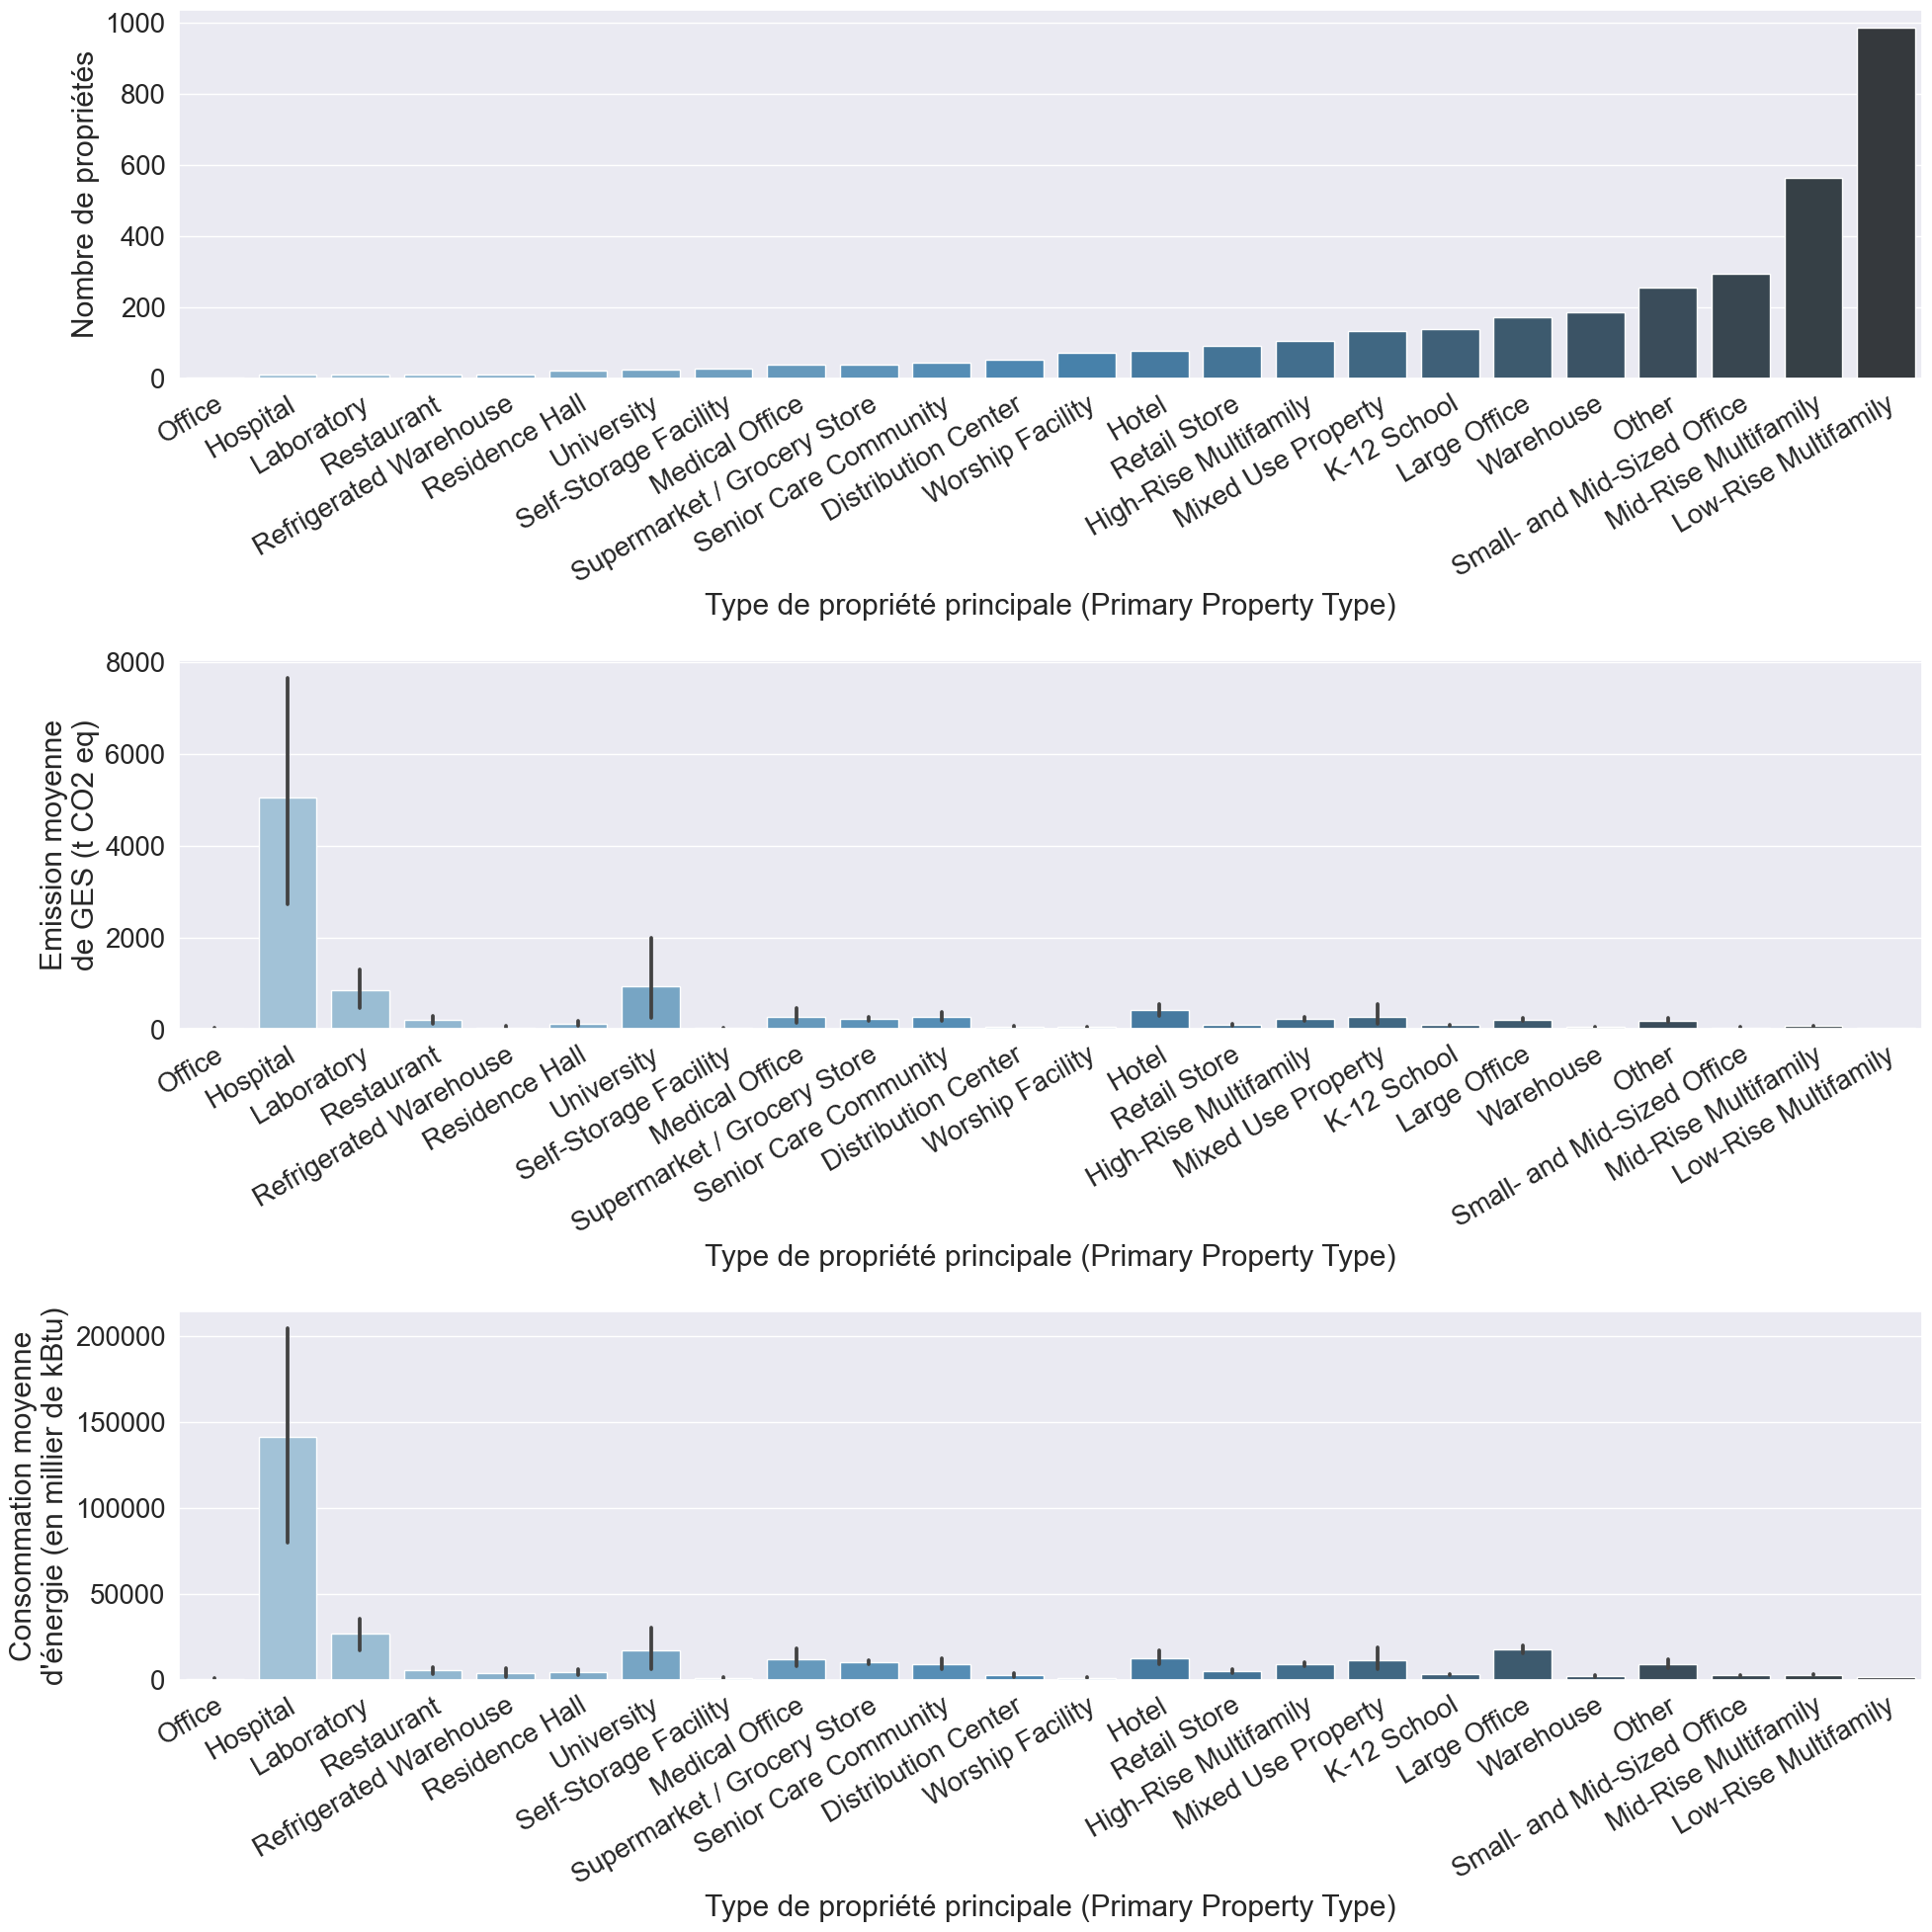

In [17]:
#on retrouve les usages précédents en regroupé
sns.set(font_scale=1.8)


order_P = data_2016['PrimaryPropertyType'].value_counts().sort_values().index


fig, axes = plt.subplots(nrows= 3,figsize=(20, 20))

sns.barplot(x=data_2016['PrimaryPropertyType'].value_counts().sort_values().index,
            y=data_2016['PrimaryPropertyType'].value_counts().sort_values(),
              ax=axes[0],
              palette="Blues_d"
            )
sns.barplot(x=data_2016['PrimaryPropertyType'],
                 y=data_2016['TotalGHGEmissions'],
                 order=order_P,
                 data=data_2016,palette="Blues_d",
                 ax=axes[1])

sns.barplot(x=data_2016['PrimaryPropertyType'],
                y=data_2016['SiteEnergyUseWN(kBtu)']/1000,
                order=order_P,
                data=data_2016,palette="Blues_d",
                ax=axes[2])


for i in range (3):
    axes[i].set_xlabel('Type de propriété principale (Primary Property Type)')  
    axes[i].set_xticklabels( axes[i].get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor' )

axes[0].set_ylabel("Nombre de propriétés")
axes[1].set_ylabel("Emission moyenne""\n""de GES (t CO2 eq)")
axes[2].set_ylabel("Consommation moyenne""\n""d'énergie (en millier de kBtu)")

plt.tight_layout()
plt.show()

# C- Type de bâtiments (BuildingType)

In [18]:
data_2016["BuildingType"].value_counts()

NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: BuildingType, dtype: int64

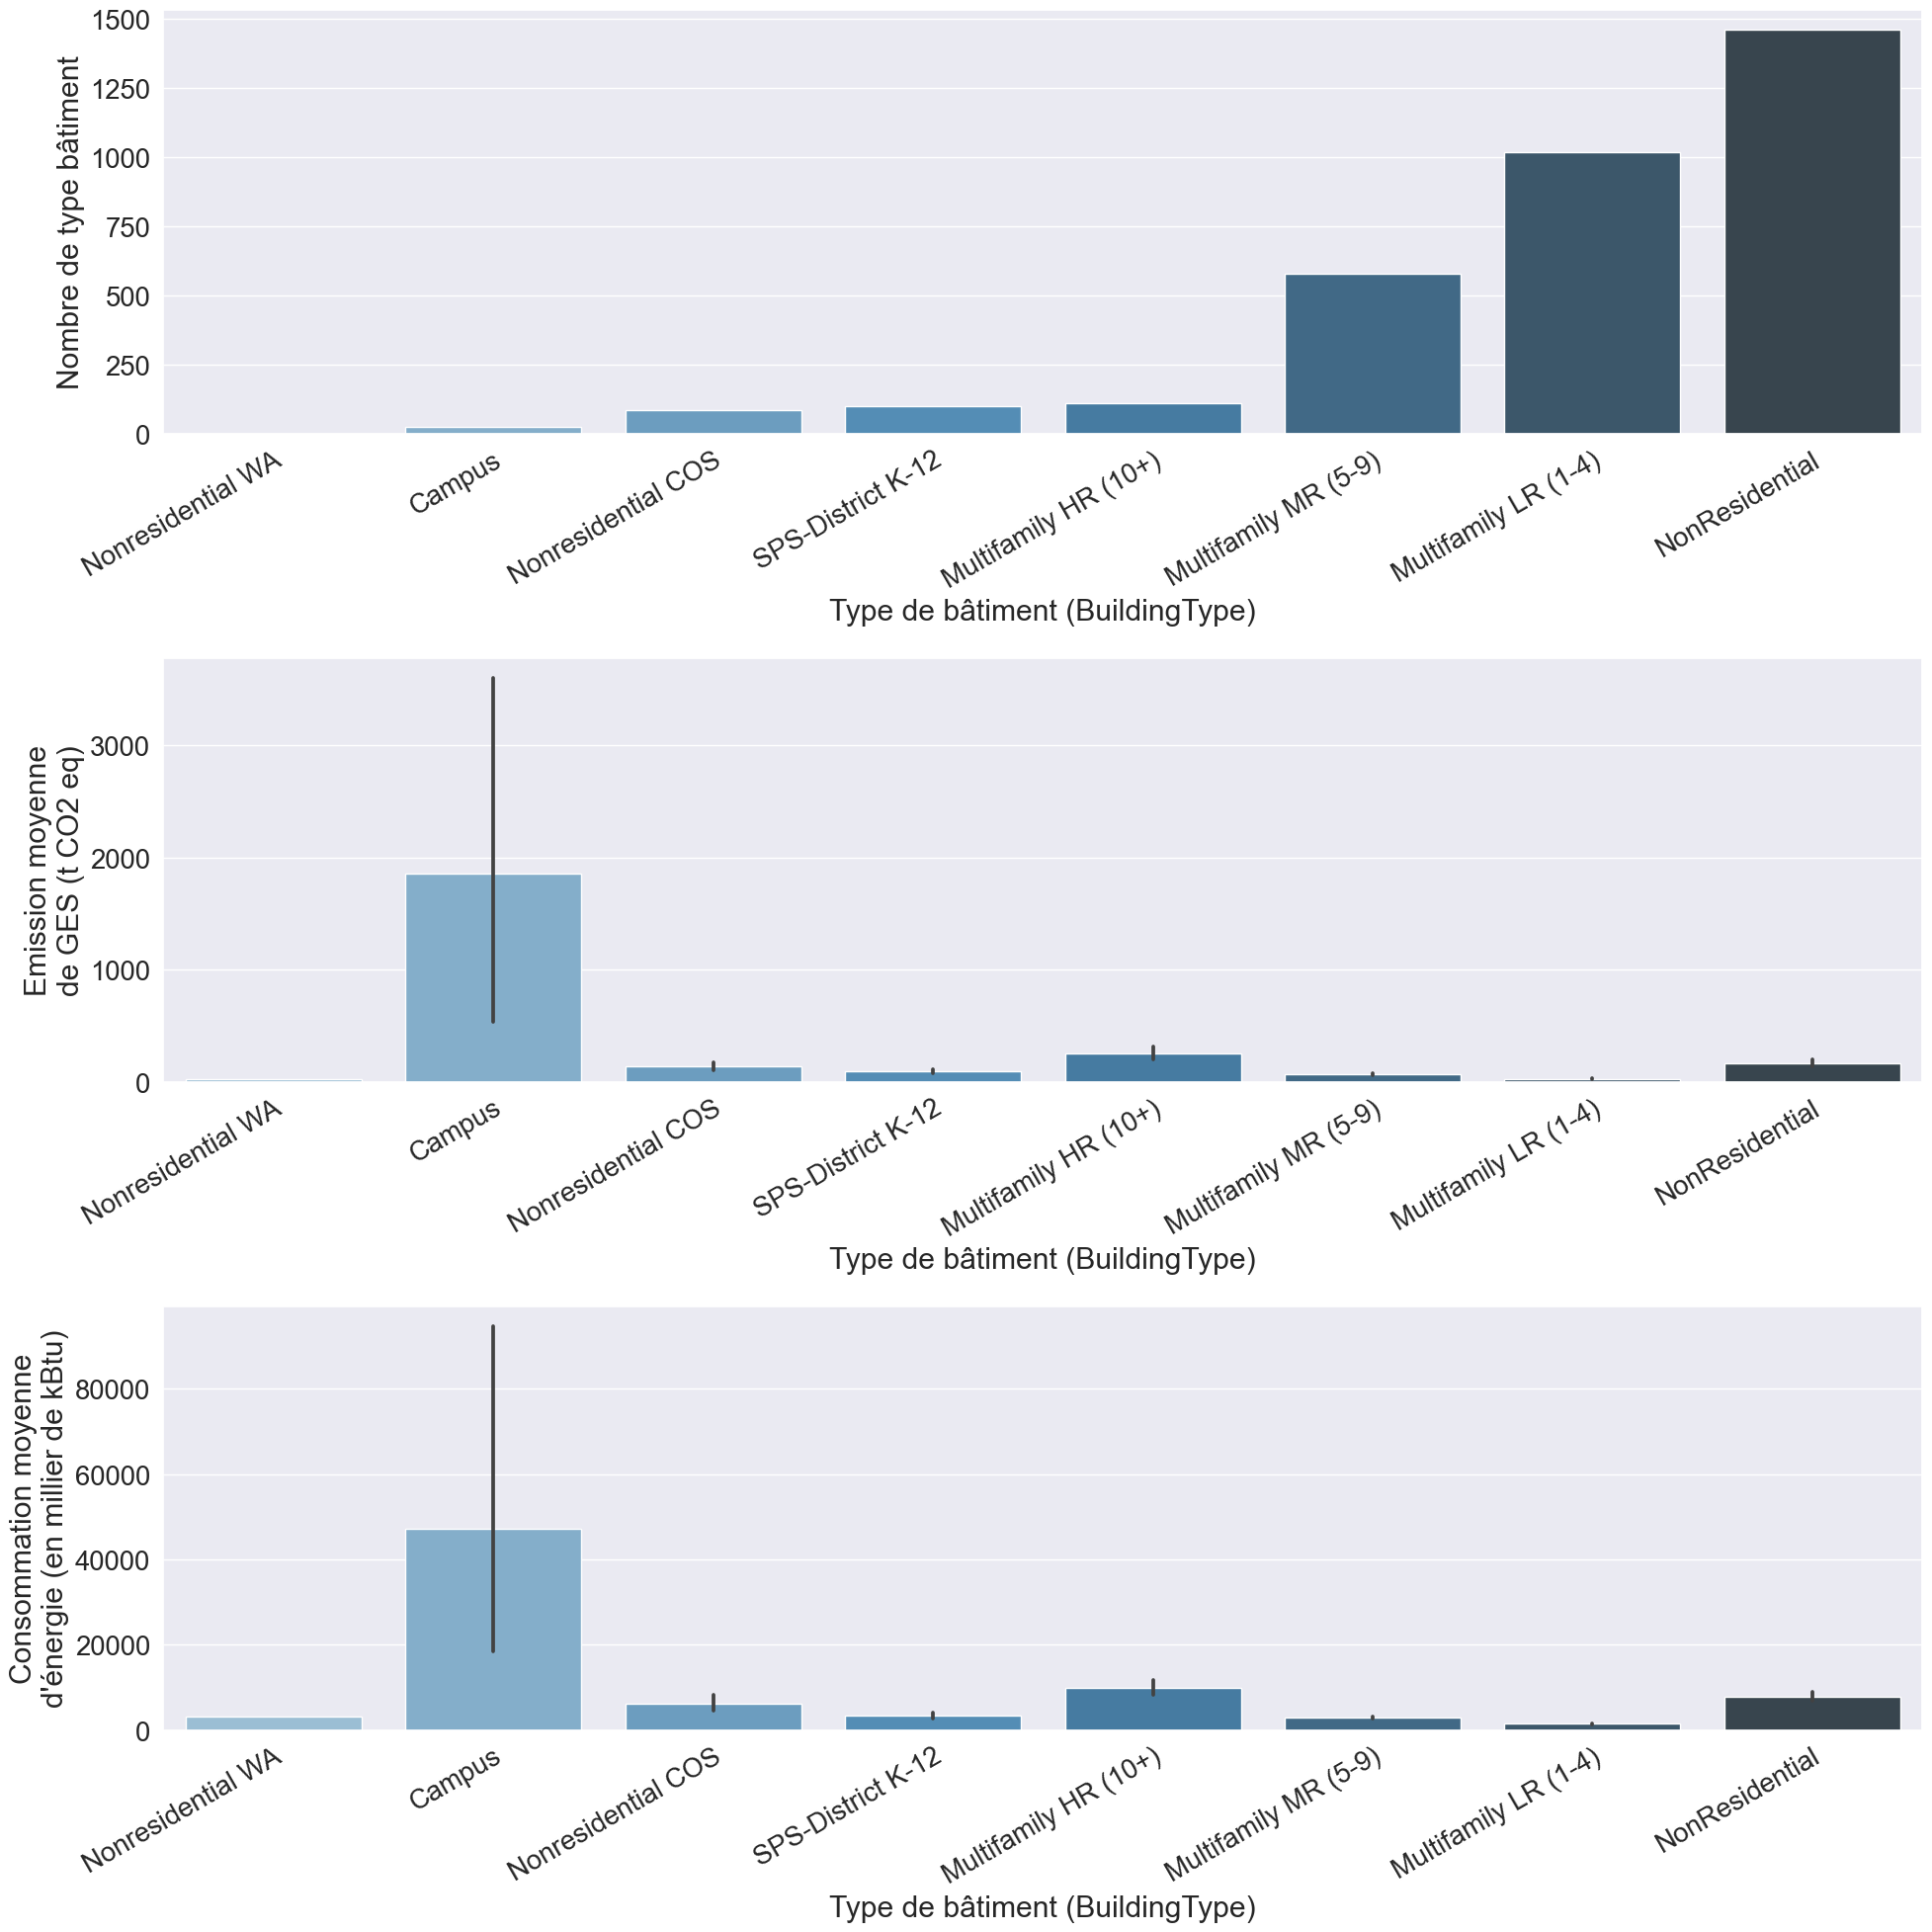

In [19]:
sns.set(font_scale=1.8)


order_P = data_2016["BuildingType"].value_counts().sort_values().index


fig, axes = plt.subplots(nrows= 3,figsize=(20, 20))

sns.barplot(x=data_2016["BuildingType"].value_counts().sort_values().index,
            y=data_2016["BuildingType"].value_counts().sort_values(),
              ax=axes[0],
              palette="Blues_d"
            )
sns.barplot(x=data_2016["BuildingType"],
                 y=data_2016['TotalGHGEmissions'],
                 order=order_P,
                 data=data_2016,palette="Blues_d",
                 ax=axes[1])

sns.barplot(x=data_2016["BuildingType"],
                y=data_2016['SiteEnergyUseWN(kBtu)']/1000,
                order=order_P,
                data=data_2016,palette="Blues_d",
                ax=axes[2])


for i in range (3):
    axes[i].set_xlabel('Type de bâtiment (BuildingType)')  
    axes[i].set_xticklabels( axes[i].get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor' )

axes[0].set_ylabel("Nombre de type bâtiment")
axes[1].set_ylabel("Emission moyenne""\n""de GES (t CO2 eq)")
axes[2].set_ylabel("Consommation moyenne""\n""d'énergie (en millier de kBtu)")

plt.tight_layout()
plt.show()

# suppresion les lignes des bâtiments à usage d'habitation

In [20]:
# je retiens que les batiments non destines à l'habitation:
type_habitat=data_2016["BuildingType"].unique()


In [21]:
type_habitat

array(['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Multifamily HR (10+)', 'Nonresidential WA'], dtype=object)

In [22]:
habitat_residentiel=['Multifamily MR (5-9)','Multifamily LR (1-4)','Multifamily HR (10+)']

In [23]:
data_2016=data_2016[~data_2016["BuildingType"].isin(habitat_residentiel)]

In [24]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1668 entries, 0 to 3375
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1668 non-null   int64  
 1   BuildingType                     1668 non-null   object 
 2   PrimaryPropertyType              1668 non-null   object 
 3   PropertyName                     1668 non-null   object 
 4   Address                          1668 non-null   object 
 5   ZipCode                          1652 non-null   float64
 6   TaxParcelIdentificationNumber    1668 non-null   object 
 7   CouncilDistrictCode              1668 non-null   int64  
 8   Neighborhood                     1668 non-null   object 
 9   Latitude                         1668 non-null   float64
 10  Longitude                        1668 non-null   float64
 11  YearBuilt                        1668 non-null   int64  
 12  NumberofBuildings   

# Analyse des indicateurs Géographique

# A - quartier (neighborhood)

In [25]:
data_2016["Neighborhood"].value_counts()

DOWNTOWN                  361
GREATER DUWAMISH          346
MAGNOLIA / QUEEN ANNE     151
LAKE UNION                148
NORTHEAST                 128
EAST                      121
NORTHWEST                  81
BALLARD                    64
NORTH                      58
CENTRAL                    51
SOUTHEAST                  46
DELRIDGE                   42
SOUTHWEST                  41
North                       9
Ballard                     6
Central                     5
Northwest                   5
Delridge                    4
DELRIDGE NEIGHBORHOODS      1
Name: Neighborhood, dtype: int64

In [26]:
#il y'a des tipographie differente pour la meme

data_2016["Neighborhood"]=data_2016["Neighborhood"].str.upper()

C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\1074336539.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2016["Neighborhood"]=data_2016["Neighborhood"].str.upper()


In [27]:
data_2016["Neighborhood"].value_counts()

DOWNTOWN                  361
GREATER DUWAMISH          346
MAGNOLIA / QUEEN ANNE     151
LAKE UNION                148
NORTHEAST                 128
EAST                      121
NORTHWEST                  86
BALLARD                    70
NORTH                      67
CENTRAL                    56
SOUTHEAST                  46
DELRIDGE                   46
SOUTHWEST                  41
DELRIDGE NEIGHBORHOODS      1
Name: Neighborhood, dtype: int64

In [28]:
# remplcer DELRIDGE NEIGHBORHOODS par DELRIDGE
data_2016["Neighborhood"].replace('DELRIDGE NEIGHBORHOODS','DELRIDGE',inplace=True)
data_2016["Neighborhood"].value_counts()

C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\1937726463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2016["Neighborhood"].replace('DELRIDGE NEIGHBORHOODS','DELRIDGE',inplace=True)


DOWNTOWN                 361
GREATER DUWAMISH         346
MAGNOLIA / QUEEN ANNE    151
LAKE UNION               148
NORTHEAST                128
EAST                     121
NORTHWEST                 86
BALLARD                   70
NORTH                     67
CENTRAL                   56
DELRIDGE                  47
SOUTHEAST                 46
SOUTHWEST                 41
Name: Neighborhood, dtype: int64

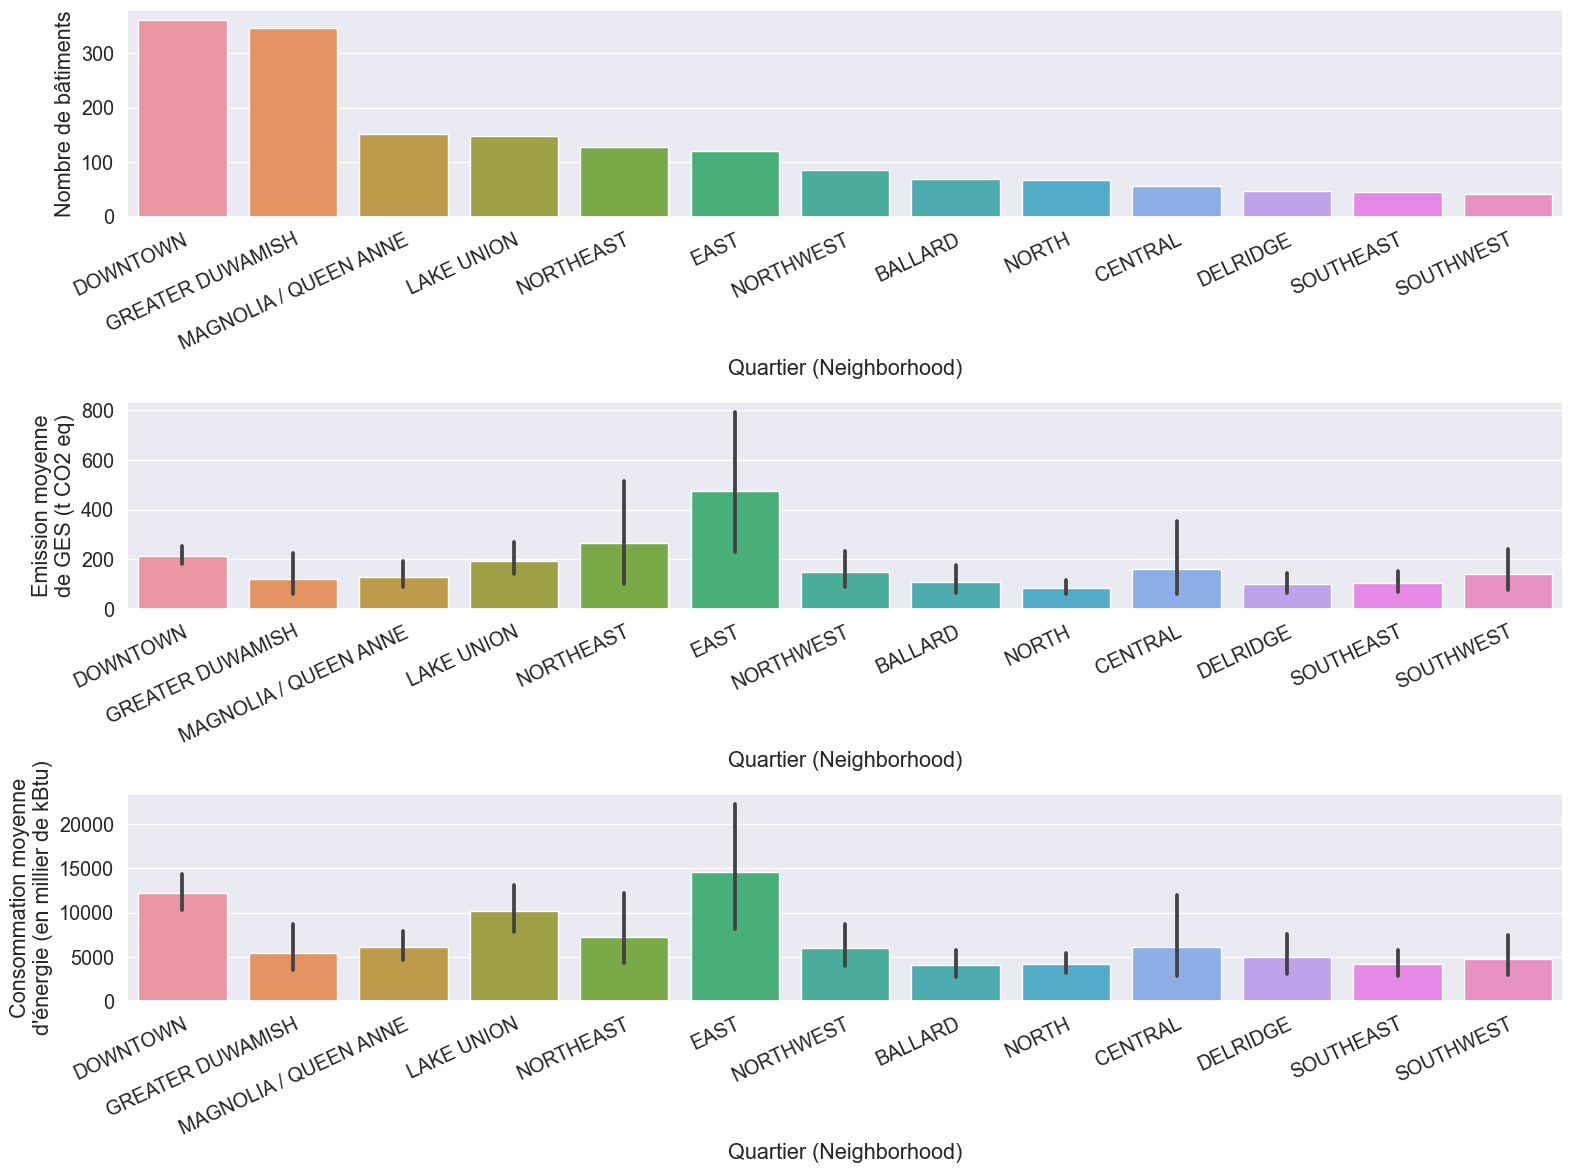

In [29]:
# Représentations graphiques de nombre de bâtiments, la conso moyenne et les émissions de GES moyennes par quartier

sns.set(font_scale=1.3)


order_N = data_2016['Neighborhood'].value_counts().index


fig, axes = plt.subplots(nrows= 3,figsize=(16, 12))

sns.barplot(x=data_2016['Neighborhood'].value_counts().index,
                 y=data_2016['Neighborhood'].value_counts(),
                 ax=axes[0]
                 #palette="Blues_d",
                 #data=df
                 )

sns.barplot(x=data_2016['Neighborhood'],
                 y=data_2016['TotalGHGEmissions'],
                #palette="Blues_d",
                 order=order_N,
                 data=data_2016,
                 ax=axes[1])

sns.barplot(x=data_2016['Neighborhood'],
                y=data_2016['SiteEnergyUseWN(kBtu)']/1000,
                #palette="Blues_d",
                order=order_N,
                data=data_2016,
                ax=axes[2])


    
for i in range (3):
    axes[i].set_xticklabels( axes[i].get_xticklabels(), rotation=25, ha='right', rotation_mode='anchor' )
    axes[i].set_xlabel('Quartier (Neighborhood)')

axes[0].set_ylabel("Nombre de bâtiments")
axes[1].set_ylabel("Emission moyenne""\n""de GES (t CO2 eq)")
axes[2].set_ylabel("Consommation moyenne""\n""d'énergie (en millier de kBtu)")

plt.tight_layout()
plt.show()

# B - District(CouncilDistrictCode)

In [30]:
data_2016['CouncilDistrictCode'].value_counts()

7    529
2    397
3    203
4    173
5    132
1    119
6    115
Name: CouncilDistrictCode, dtype: int64

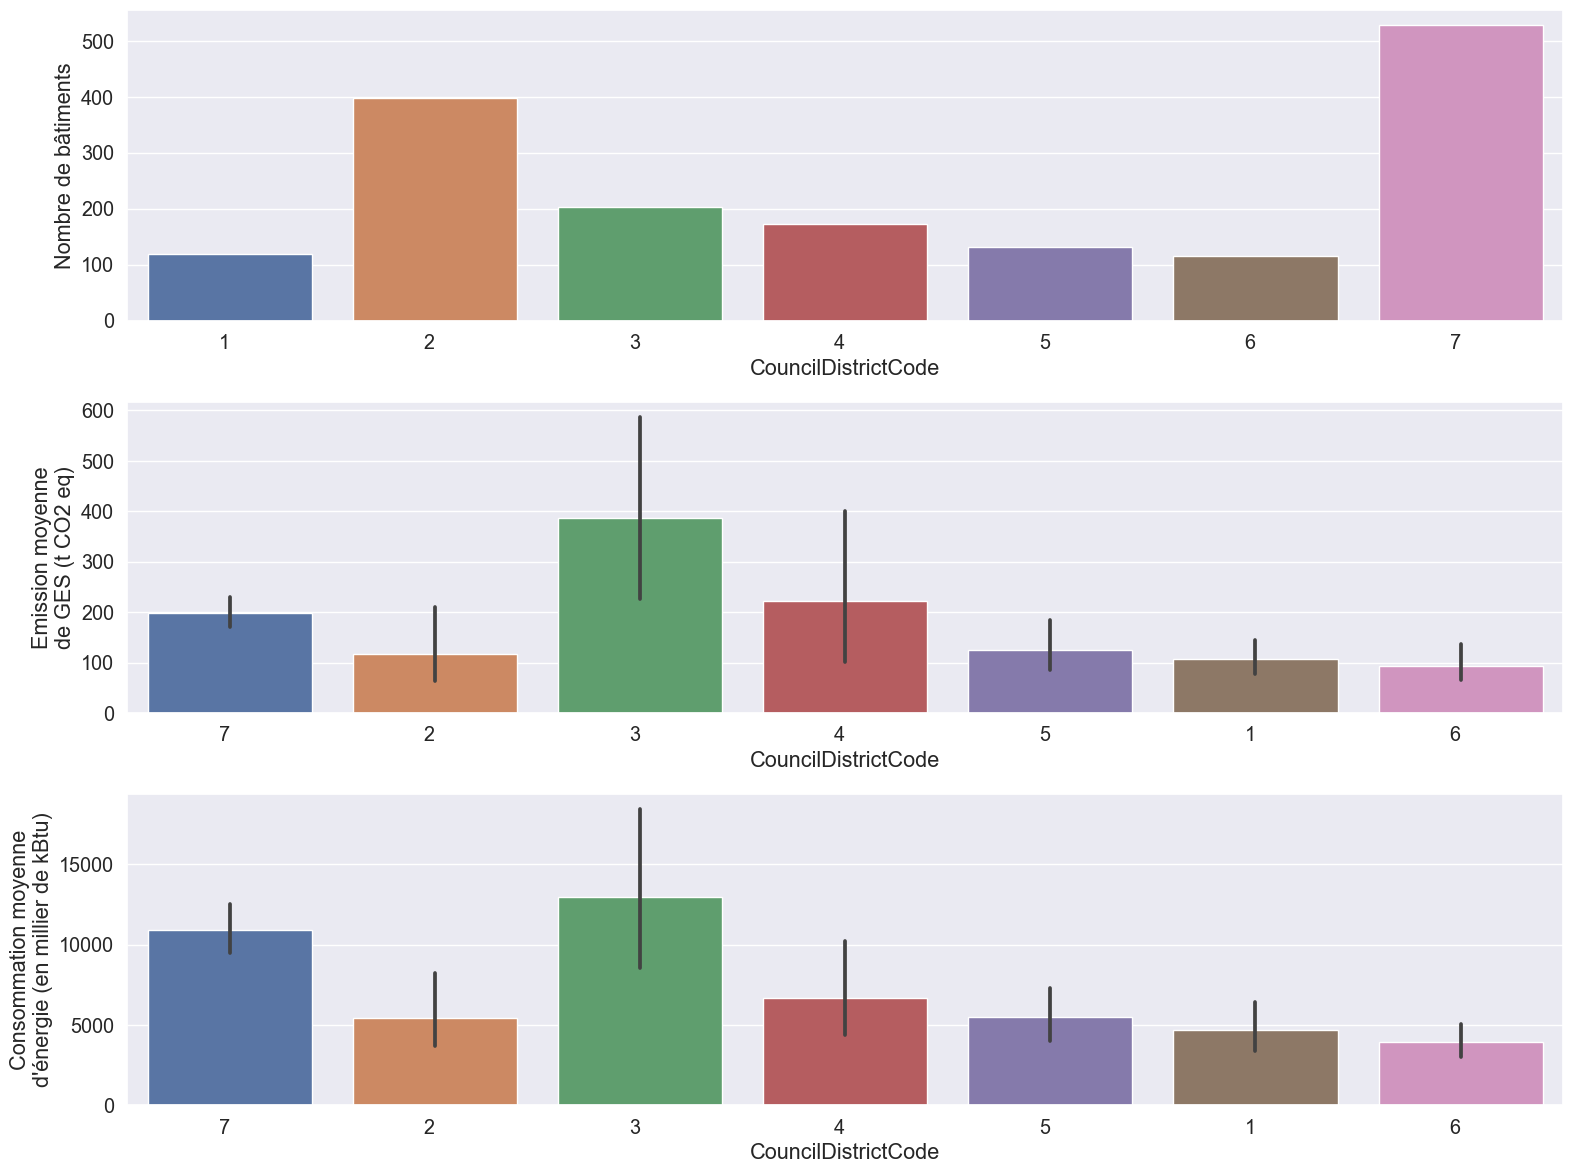

In [31]:
# Représentations graphiques de nombre de bâtiments, la conso moyenne et les émissions de GES moyennes par code district

sns.set(font_scale=1.3)


order_N = data_2016['CouncilDistrictCode'].value_counts().index


fig, axes = plt.subplots(nrows= 3,figsize=(16, 12))

sns.barplot(x=data_2016['CouncilDistrictCode'].value_counts().index,
                 y=data_2016['CouncilDistrictCode'].value_counts(),
                 ax=axes[0]
                 #palette="Blues_d",
                 #data=df
                 )

sns.barplot(x=data_2016['CouncilDistrictCode'],
                 y=data_2016['TotalGHGEmissions'],
                #palette="Blues_d",
                 order=order_N,
                 data=data_2016,
                 ax=axes[1])

sns.barplot(x=data_2016['CouncilDistrictCode'],
                y=data_2016['SiteEnergyUseWN(kBtu)']/1000,
                #palette="Blues_d",
                order=order_N,
                data=data_2016,
                ax=axes[2])


    
for i in range (3):
    axes[i].set_xticklabels( axes[i].get_xticklabels(), rotation=0, ha='right', rotation_mode='anchor' )
    axes[i].set_xlabel('CouncilDistrictCode')

axes[0].set_ylabel("Nombre de bâtiments")
axes[1].set_ylabel("Emission moyenne""\n""de GES (t CO2 eq)")
axes[2].set_ylabel("Consommation moyenne""\n""d'énergie (en millier de kBtu)")

plt.tight_layout()
plt.show()

# C- Latitude et Longitude

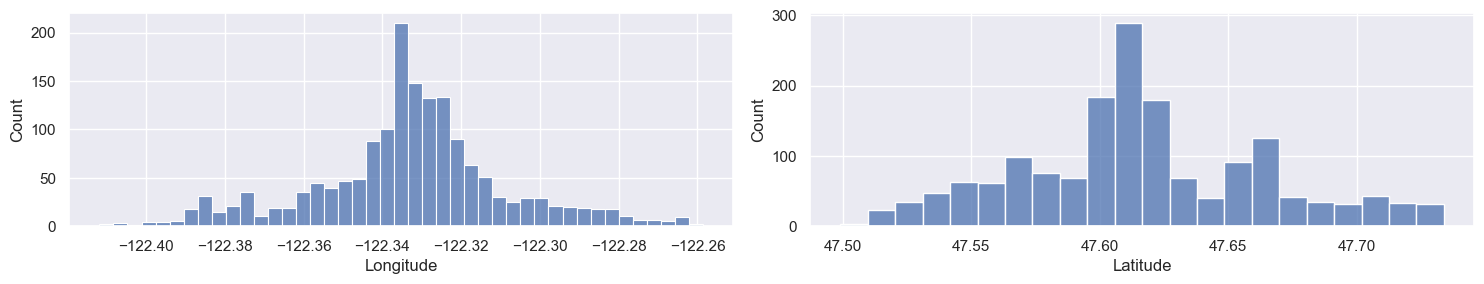

In [32]:
sns.set(font_scale=1)
fig, axes = plt.subplots(ncols = 2,figsize=(15, 3))
g=sns.histplot(data_2016, x="Longitude",cbar=True, 
               #bins=25, 
               ax=axes[0])
g2=sns.histplot(data_2016, x="Latitude",cbar=True,
                #bins=25,
                ax=axes[1])
plt.tight_layout()

# IV Analyse des indicateurs architecturaux

In [33]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1668 entries, 0 to 3375
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1668 non-null   int64  
 1   BuildingType                     1668 non-null   object 
 2   PrimaryPropertyType              1668 non-null   object 
 3   PropertyName                     1668 non-null   object 
 4   Address                          1668 non-null   object 
 5   ZipCode                          1652 non-null   float64
 6   TaxParcelIdentificationNumber    1668 non-null   object 
 7   CouncilDistrictCode              1668 non-null   int64  
 8   Neighborhood                     1668 non-null   object 
 9   Latitude                         1668 non-null   float64
 10  Longitude                        1668 non-null   float64
 11  YearBuilt                        1668 non-null   int64  
 12  NumberofBuildings   

In [34]:
# valeurs manquantes par variable
data_2016.isna().sum()

OSEBuildingID                         0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
Address                               0
ZipCode                              16
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     2
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             2
LargestPropertyUseType                6
LargestPropertyUseTypeGFA             6
SecondLargestPropertyUseType        813
SecondLargestPropertyUseTypeGFA     813
ThirdLargestPropertyUseType        1315
ThirdLargestPropertyUseTypeGFA     1315
YearsENERGYSTARCertified           1570


In [35]:
data_2016['PropertyGFATotal'].value_counts()

25920     7
36000     7
28800     7
21600     6
24000     5
         ..
141890    1
108753    1
63644     1
111908    1
18258     1
Name: PropertyGFATotal, Length: 1590, dtype: int64

In [36]:
data_2016['PropertyGFAParking'].value_counts()

0         1335
13320        3
10800        2
30000        2
25800        2
          ... 
47656        1
115228       1
33921        1
44728        1
85028        1
Name: PropertyGFAParking, Length: 327, dtype: int64

In [37]:

# Création d'une colonne : le rapport entre la taille d'usage majoritaire et la taille totale:
data_2016['Largest_UseType_per']=(data_2016['LargestPropertyUseTypeGFA']/data_2016['PropertyGFATotal']).round(3)

C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\2977484374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2016['Largest_UseType_per']=(data_2016['LargestPropertyUseTypeGFA']/data_2016['PropertyGFATotal']).round(3)


In [38]:
data_2016['LargestPropertyUseTypeGFA'].value_counts()

24000.0     6
30000.0     6
22000.0     5
36000.0     5
21600.0     5
           ..
44300.0     1
129420.0    1
119593.0    1
99551.0     1
8271.0      1
Name: LargestPropertyUseTypeGFA, Length: 1561, dtype: int64

In [39]:
data_2016['Largest_UseType_per'].value_counts()

1.000    558
0.500      7
0.750      6
0.928      6
0.970      6
        ... 
0.744      1
0.631      1
1.638      1
0.490      1
0.404      1
Name: Largest_UseType_per, Length: 622, dtype: int64

In [40]:
data_2016['Largest_UseType_per'].describe()

count    1662.000000
mean        0.870276
std         0.305471
min         0.186000
25%         0.693250
50%         0.966000
75%         1.000000
max         6.427000
Name: Largest_UseType_per, dtype: float64

In [ ]:
# un max de 6.427 valeur aberrante

In [41]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1668 entries, 0 to 3375
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1668 non-null   int64  
 1   BuildingType                     1668 non-null   object 
 2   PrimaryPropertyType              1668 non-null   object 
 3   PropertyName                     1668 non-null   object 
 4   Address                          1668 non-null   object 
 5   ZipCode                          1652 non-null   float64
 6   TaxParcelIdentificationNumber    1668 non-null   object 
 7   CouncilDistrictCode              1668 non-null   int64  
 8   Neighborhood                     1668 non-null   object 
 9   Latitude                         1668 non-null   float64
 10  Longitude                        1668 non-null   float64
 11  YearBuilt                        1668 non-null   int64  
 12  NumberofBuildings   

In [42]:
# un max>1 , des valeurs aberrantes existent dans les mesures LargestPropertyUseTypeGFA >PropertyGFATotal : des valeurs à supprimer 
data_2016['Largest_UseType_per'] = data_2016['Largest_UseType_per'].apply(lambda x: x if x <= 1 else None)

data_2016.dropna(subset=['Largest_UseType_per'], inplace=True)


C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\4072722514.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2016['Largest_UseType_per'] = data_2016['Largest_UseType_per'].apply(lambda x: x if x <= 1 else None)
C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\4072722514.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2016.dropna(subset=['Largest_UseType_per'], inplace=True)


In [43]:
#Après suppression de ces valeurs:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1456 entries, 0 to 3375
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1456 non-null   int64  
 1   BuildingType                     1456 non-null   object 
 2   PrimaryPropertyType              1456 non-null   object 
 3   PropertyName                     1456 non-null   object 
 4   Address                          1456 non-null   object 
 5   ZipCode                          1440 non-null   float64
 6   TaxParcelIdentificationNumber    1456 non-null   object 
 7   CouncilDistrictCode              1456 non-null   int64  
 8   Neighborhood                     1456 non-null   object 
 9   Latitude                         1456 non-null   float64
 10  Longitude                        1456 non-null   float64
 11  YearBuilt                        1456 non-null   int64  
 12  NumberofBuildings   

In [ ]:
# Transformer YearBuilt en Age:

In [44]:


data_2016['Age']=2016 - data_2016['YearBuilt']

# placer Age avant YearBuilt:
data_2016=data_2016[['Age']+ [col for col in data_2016.columns if col != 'Age' and col != 'Year Built']]

C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\3471320284.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2016['Age']=2016 - data_2016['YearBuilt']


In [45]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1456 entries, 0 to 3375
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              1456 non-null   int64  
 1   OSEBuildingID                    1456 non-null   int64  
 2   BuildingType                     1456 non-null   object 
 3   PrimaryPropertyType              1456 non-null   object 
 4   PropertyName                     1456 non-null   object 
 5   Address                          1456 non-null   object 
 6   ZipCode                          1440 non-null   float64
 7   TaxParcelIdentificationNumber    1456 non-null   object 
 8   CouncilDistrictCode              1456 non-null   int64  
 9   Neighborhood                     1456 non-null   object 
 10  Latitude                         1456 non-null   float64
 11  Longitude                        1456 non-null   float64
 12  YearBuilt           

In [46]:
# suuprimer YearBuilt:
data_2016.drop('YearBuilt',axis=1,inplace=True)

# V - Analyse des Indicateurs energetique:

In [47]:
list_Columns = ['SiteEUI(kBtu/sf)',
               'SiteEUIWN(kBtu/sf)',
               'SourceEUI(kBtu/sf)',
               'SourceEUIWN(kBtu/sf)',
               'SiteEnergyUse(kBtu)',
               'SiteEnergyUseWN(kBtu)',
               'SteamUse(kBtu)',
                
               'NaturalGas(kBtu)',
               'Electricity(kBtu)',
               'TotalGHGEmissions']
data_2016[list_Columns].describe()

,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),NaturalGas(kBtu),Electricity(kBtu),TotalGHGEmissions
count,1455.000000,1455.000000,1456.000000,1456.000000,1.456000e+03,1.455000e+03,1.456000e+03,1.456000e+03,1.456000e+03,1456.000000
mean,72.366735,74.691615,177.662225,179.852610,7.939665e+06,7.464628e+06,3.972175e+05,1.664168e+06,5.750739e+06,159.135103
std,74.366703,75.306908,189.522743,189.613050,2.843271e+07,1.732821e+07,4.453569e+06,5.589935e+06,2.117623e+07,562.515937
min,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.154170e+05,-0.800000
25%,34.000000,35.650000,77.875002,80.574999,1.208034e+06,1.263704e+06,0.000000e+00,0.000000e+00,7.102040e+05,19.800000
50%,52.400002,54.799999,134.450005,136.100006,2.498541e+06,2.626698e+06,0.000000e+00,4.608510e+05,1.580550e+06,49.145000
75%,82.549999,85.750000,205.949997,206.825001,6.838639e+06,7.020947e+06,0.000000e+00,1.397062e+06,4.795924e+06,134.600000
max,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,2.959299e+08,1.349435e+08,1.381912e+08,6.570744e+08,12307.160000


In [ ]:
# supprimer les lignes où les valeurs <=0 :

In [48]:


data_2016[(data_2016['SiteEnergyUseWN(kBtu)'] <= 0) | (data_2016['TotalGHGEmissions'] <= 0)].T

data_2016 =data_2016[(data_2016['SiteEnergyUseWN(kBtu)'] > 0) & (data_2016['TotalGHGEmissions'] > 0)]




In [49]:
data_2016[list_Columns].describe()

,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),NaturalGas(kBtu),Electricity(kBtu),TotalGHGEmissions
count,1436.000000,1436.000000,1436.000000,1436.000000,1.436000e+03,1.436000e+03,1.436000e+03,1.436000e+03,1.436000e+03,1436.000000
mean,72.616574,75.527298,178.742410,182.358983,7.346608e+06,7.554282e+06,3.339779e+05,1.680437e+06,5.310495e+06,152.048719
std,74.391016,75.249592,189.896820,189.727576,1.716035e+07,1.742176e+07,3.877797e+06,5.625405e+06,1.256586e+07,485.928667
min,0.700000,0.700000,0.000000,0.000000,1.680890e+04,1.726000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.120000
25%,34.175000,36.524999,78.475000,82.225002,1.217961e+06,1.294392e+06,0.000000e+00,0.000000e+00,7.159440e+05,19.887500
50%,52.549999,55.400000,135.500000,137.400002,2.500610e+06,2.657640e+06,0.000000e+00,4.835180e+05,1.580550e+06,49.215000
75%,82.525000,86.500000,205.949997,209.024994,6.838639e+06,7.052678e+06,0.000000e+00,1.402203e+06,4.795924e+06,133.780000
max,834.400024,834.400024,2620.000000,2620.000000,2.916144e+08,2.959299e+08,1.349435e+08,1.381912e+08,2.745325e+08,12307.160000


In [50]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1436 entries, 0 to 3375
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              1436 non-null   int64  
 1   OSEBuildingID                    1436 non-null   int64  
 2   BuildingType                     1436 non-null   object 
 3   PrimaryPropertyType              1436 non-null   object 
 4   PropertyName                     1436 non-null   object 
 5   Address                          1436 non-null   object 
 6   ZipCode                          1420 non-null   float64
 7   TaxParcelIdentificationNumber    1436 non-null   object 
 8   CouncilDistrictCode              1436 non-null   int64  
 9   Neighborhood                     1436 non-null   object 
 10  Latitude                         1436 non-null   float64
 11  Longitude                        1436 non-null   float64
 12  NumberofBuildings   

In [51]:
# supprimer toutes les colonnes avec les nanall (colonnes vides): colonne Comments

data_2016=data_2016.drop(data_2016.columns[data_2016.isna().all()],axis=1)

In [52]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1436 entries, 0 to 3375
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              1436 non-null   int64  
 1   OSEBuildingID                    1436 non-null   int64  
 2   BuildingType                     1436 non-null   object 
 3   PrimaryPropertyType              1436 non-null   object 
 4   PropertyName                     1436 non-null   object 
 5   Address                          1436 non-null   object 
 6   ZipCode                          1420 non-null   float64
 7   TaxParcelIdentificationNumber    1436 non-null   object 
 8   CouncilDistrictCode              1436 non-null   int64  
 9   Neighborhood                     1436 non-null   object 
 10  Latitude                         1436 non-null   float64
 11  Longitude                        1436 non-null   float64
 12  NumberofBuildings   

In [53]:
data_2016.columns

Index(['Age', 'OSEBuildingID', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'DefaultData', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'

Définition des variables:
Variables

OSEBuildingID : L'ID du batiment

DataYear : Année de consommation

BuildingType : Type de Building (Résidence ou pas)

PrimaryPropertyType : Type de propriété (Hotel, Ecole...)

PropertyName : Nom du bâtiment

Address : L'adresse du bâtiment

City : La ville ou est situé le bâtiment

State : L'état ou est situé le bâtiment

ZipCode : Code postal (peut etre différent même dans un même état)

TaxParcelIdentificationNumber : Numero identification (fiscale)

CouncilDistrictCode : code du district du conseil de la ville de Seattle

Neighborhood : Quartier

Latitude : La latitude Longitude : La longitude

YearBuilt : Date de création ou de rénovation

NumberofBuildings : Nombre de buildings dans la propriété

NumberofFloors : Nombre d'étages

PropertyGFATotal : Surface brute de plancher totale du bâtiment et du parking

PropertyGFAParking : Espace brute de tous les types de stationnement

PropertyGFABuilding(s) : Surface brute du bâtiment

ListOfAllPropertyUseTypes : Types d'utilisation de la propriété

LargestPropertyUseType : Type d'utilisation principale de la propriété

LargestPropertyUseTypeGFA : Surface brute de plancher (Utilisation principale)

SecondLargestPropertyUseType : Type d'utilisation secondaire de la propriété

SecondLargestPropertyUseTypeGFA: Surface brute de plancher (Utilisation secondaire)

ThirdLargestPropertyUseType : Type d'utilisation tertiaire de la propriété

ThirdLargestPropertyUseTypeGFA : Surface brute de plancher (Utilisation tertiaire)

YearsENERGYSTARCertified : Année auquel la propriété a recu la certification ENERGYSTAR

ENERGYSTARScore : Score (de 1 a 100) qui calcule la performance énergétique d'un bien immobilier

SiteEUI(kBtu/sf) : Energie annuelle consommée d'un bien immobilier / Surface brute de plancher

SiteEUIWN(kBtu/sf) : SiteEUI(kBtu/sf) normalisée en fonctions des conditions météologiques

SourceEUI(kBtu/sf) : Energie annuelle consommée d'un bien immobilier (y compris les pertes) / Surface brute de plancher

SourceEUIWN(kBtu/sf) : SourceEUI(kBtu/sf) normalisée en fonctions des conditions météologiques

SiteEnergyUse(kBtu) : Quantité annuelle d'énergie consommée, toutes sources d'énergie confondues

SiteEnergyUseWN(kBtu) : SiteEnergyUse(kBtu) normalisée en fonctions des conditions météologiques

SteamUse(kBtu) : Quantité annuelle de vapeur urbaine consommée

Electricity(kWh) : Quantité annuelle d'électricité consommée

Electricity(kBtu) : Electricity mais en British thermal units (kBtu)

NaturalGas(therms) : Quantité annuelle de gaz naturel consommée (therms)

NaturalGas(kBtu) : NaturalGas mais en British thermal units (kBtu).

DefaultData : La propriété utilisait des données par défaut pour au moins une caractéristique de propriété.

Comments : Commentaires d’un propriétaire ou d’un agent d’immeuble pour fournir un contexte à la consommation d’énergie du bâtiment.

ComplianceStatus indique si une propriété a satisfait aux exigences d’analyse comparative énergétique pour l’année de
déclaration en cours.

Outlier :Si une propriété est une valeur aberrante élevée ou faible (O/N)

TotalGHGEmissions : Quantité totale d'émissions de (dioxyde de carbone + le méthane + l'oxyde nitreux)

GHGEmissionsIntensity : TotalGHGEmissions / Surface brute de plancher de la propriété

# Nos targets:TotalGHGEmissions et SiteEnergyUseWN(kBtu) 

In [54]:
data_2016.columns

Index(['Age', 'OSEBuildingID', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'DefaultData', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'

In [55]:

type_batiment=data_2016['BuildingType'].unique()


In [56]:
type_batiment

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus'], dtype=object)

In [60]:
# supprimer les lignes où ComplianceStatus n'est pas conforme:
data_2016['ComplianceStatus'].value_counts()

Compliant                       1359
Error - Correct Default Data      64
Non-Compliant                     13
Name: ComplianceStatus, dtype: int64

In [61]:
type_compliances=data_2016['ComplianceStatus'].unique()

In [62]:
type_compliances

array(['Compliant', 'Error - Correct Default Data', 'Non-Compliant'],
      dtype=object)

In [63]:
compliances_autre=['Error - Correct Default Data', 'Non-Compliant']

In [64]:
data_2016=data_2016[~data_2016['ComplianceStatus'].isin(compliances_autre)]

In [65]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1359 entries, 0 to 3375
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              1359 non-null   int64  
 1   OSEBuildingID                    1359 non-null   int64  
 2   BuildingType                     1359 non-null   object 
 3   PrimaryPropertyType              1359 non-null   object 
 4   PropertyName                     1359 non-null   object 
 5   Address                          1359 non-null   object 
 6   ZipCode                          1346 non-null   float64
 7   TaxParcelIdentificationNumber    1359 non-null   object 
 8   CouncilDistrictCode              1359 non-null   int64  
 9   Neighborhood                     1359 non-null   object 
 10  Latitude                         1359 non-null   float64
 11  Longitude                        1359 non-null   float64
 12  NumberofBuildings   

# Les valeurs manquantes:

In [66]:
 #supprimer les lignes où ENERGYSTARScore contiennent des nan
data_2016.dropna(subset=['ENERGYSTARScore'],inplace=True)

In [67]:
#supprimer les colonnes inutiles : outliers,YearsENERGYSTARCertified,etc...

col_drop=np.array(['OSEBuildingID','PropertyName','TaxParcelIdentificationNumber',
                 'CouncilDistrictCode', 'Neighborhood','Address','ZipCode','PrimaryPropertyType',
                  'ListOfAllPropertyUseTypes','SiteEUI(kBtu/sf)','SiteEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
                 'SiteEnergyUse(kBtu)','Electricity(kWh)','Outlier','YearsENERGYSTARCertified','GHGEmissionsIntensity','SecondLargestPropertyUseType', 
                  'SecondLargestPropertyUseTypeGFA','ThirdLargestPropertyUseType','ThirdLargestPropertyUseTypeGFA'])

In [68]:
data_2016=data_2016.drop(col_drop,axis=1)

In [69]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 3339
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        872 non-null    int64  
 1   BuildingType               872 non-null    object 
 2   Latitude                   872 non-null    float64
 3   Longitude                  872 non-null    float64
 4   NumberofBuildings          872 non-null    float64
 5   NumberofFloors             872 non-null    int64  
 6   PropertyGFATotal           872 non-null    int64  
 7   PropertyGFAParking         872 non-null    int64  
 8   PropertyGFABuilding(s)     872 non-null    int64  
 9   LargestPropertyUseType     872 non-null    object 
 10  LargestPropertyUseTypeGFA  872 non-null    float64
 11  ENERGYSTARScore            872 non-null    float64
 12  SiteEnergyUseWN(kBtu)      872 non-null    float64
 13  SteamUse(kBtu)             872 non-null    float6

In [70]:
data_2016['DefaultData'].unique()

array([False])

In [74]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 3339
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        872 non-null    int64  
 1   BuildingType               872 non-null    object 
 2   Latitude                   872 non-null    float64
 3   Longitude                  872 non-null    float64
 4   NumberofBuildings          872 non-null    float64
 5   NumberofFloors             872 non-null    int64  
 6   PropertyGFATotal           872 non-null    int64  
 7   PropertyGFAParking         872 non-null    int64  
 8   PropertyGFABuilding(s)     872 non-null    int64  
 9   LargestPropertyUseType     872 non-null    object 
 10  LargestPropertyUseTypeGFA  872 non-null    float64
 11  ENERGYSTARScore            872 non-null    float64
 12  SiteEnergyUseWN(kBtu)      872 non-null    float64
 13  SteamUse(kBtu)             872 non-null    float6

In [76]:
# supprimer DefaultData et ComplianceStatus,BuildingType:
coldrop=['DefaultData','ComplianceStatus','BuildingType']
data_2016=data_2016.drop(coldrop,axis=1)

In [77]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 3339
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        872 non-null    int64  
 1   Latitude                   872 non-null    float64
 2   Longitude                  872 non-null    float64
 3   NumberofBuildings          872 non-null    float64
 4   NumberofFloors             872 non-null    int64  
 5   PropertyGFATotal           872 non-null    int64  
 6   PropertyGFAParking         872 non-null    int64  
 7   PropertyGFABuilding(s)     872 non-null    int64  
 8   LargestPropertyUseType     872 non-null    object 
 9   LargestPropertyUseTypeGFA  872 non-null    float64
 10  ENERGYSTARScore            872 non-null    float64
 11  SiteEnergyUseWN(kBtu)      872 non-null    float64
 12  SteamUse(kBtu)             872 non-null    float64
 13  Electricity(kBtu)          872 non-null    float6

# Supression des variables fortement correlées

C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\12144034.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data_corr=data_2016.dropna().corr()


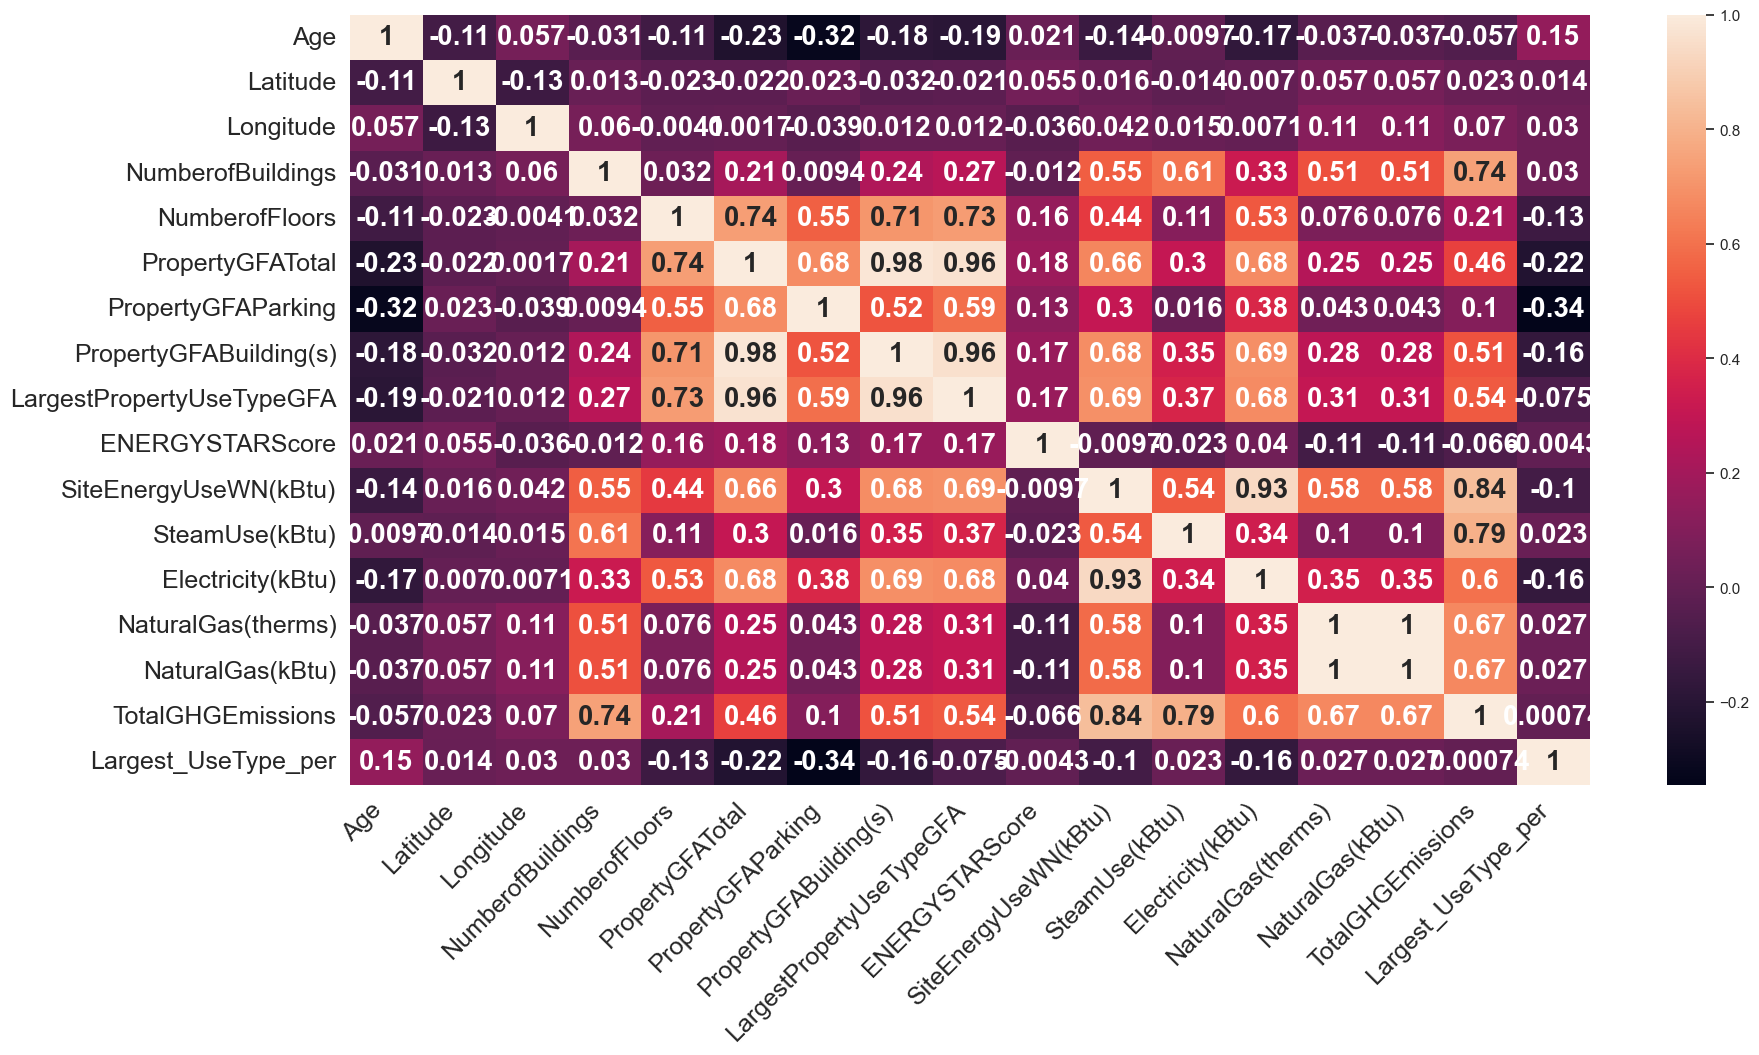

In [79]:
data_corr=data_2016.dropna().corr()
plt.figure(figsize=(20,10))
sns.heatmap(data_corr,annot=True,annot_kws={"size": 20,"fontweight":"bold"})
#plt.xlabel( "X-Axis Label",fontsize=24)
#plt.ylabel( fontsize=24)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=18)
plt.gca().set_yticklabels(plt.gca().get_yticklabels(), fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.show()

In [80]:
# les variables les plus correlées :
#PropertyGFATotal(à suuprimer) et PropertyGFABuilding,LargestPropertyUseTypeGFA(à supprimer) et PropertyGFABuilding(s)
#NaturalGas(kBtu) et NaturalGas(Therms)(àsupprimer)
col_cor_drop=['PropertyGFATotal', 'NaturalGas(therms)','LargestPropertyUseTypeGFA']
data_2016=data_2016.drop(col_cor_drop,axis=1)

In [81]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 3339
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     872 non-null    int64  
 1   Latitude                872 non-null    float64
 2   Longitude               872 non-null    float64
 3   NumberofBuildings       872 non-null    float64
 4   NumberofFloors          872 non-null    int64  
 5   PropertyGFAParking      872 non-null    int64  
 6   PropertyGFABuilding(s)  872 non-null    int64  
 7   LargestPropertyUseType  872 non-null    object 
 8   ENERGYSTARScore         872 non-null    float64
 9   SiteEnergyUseWN(kBtu)   872 non-null    float64
 10  SteamUse(kBtu)          872 non-null    float64
 11  Electricity(kBtu)       872 non-null    float64
 12  NaturalGas(kBtu)        872 non-null    float64
 13  TotalGHGEmissions       872 non-null    float64
 14  Largest_UseType_per     872 non-null    f

C:\Users\nassc\AppData\Local\Temp\ipykernel_20596\12144034.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data_corr=data_2016.dropna().corr()


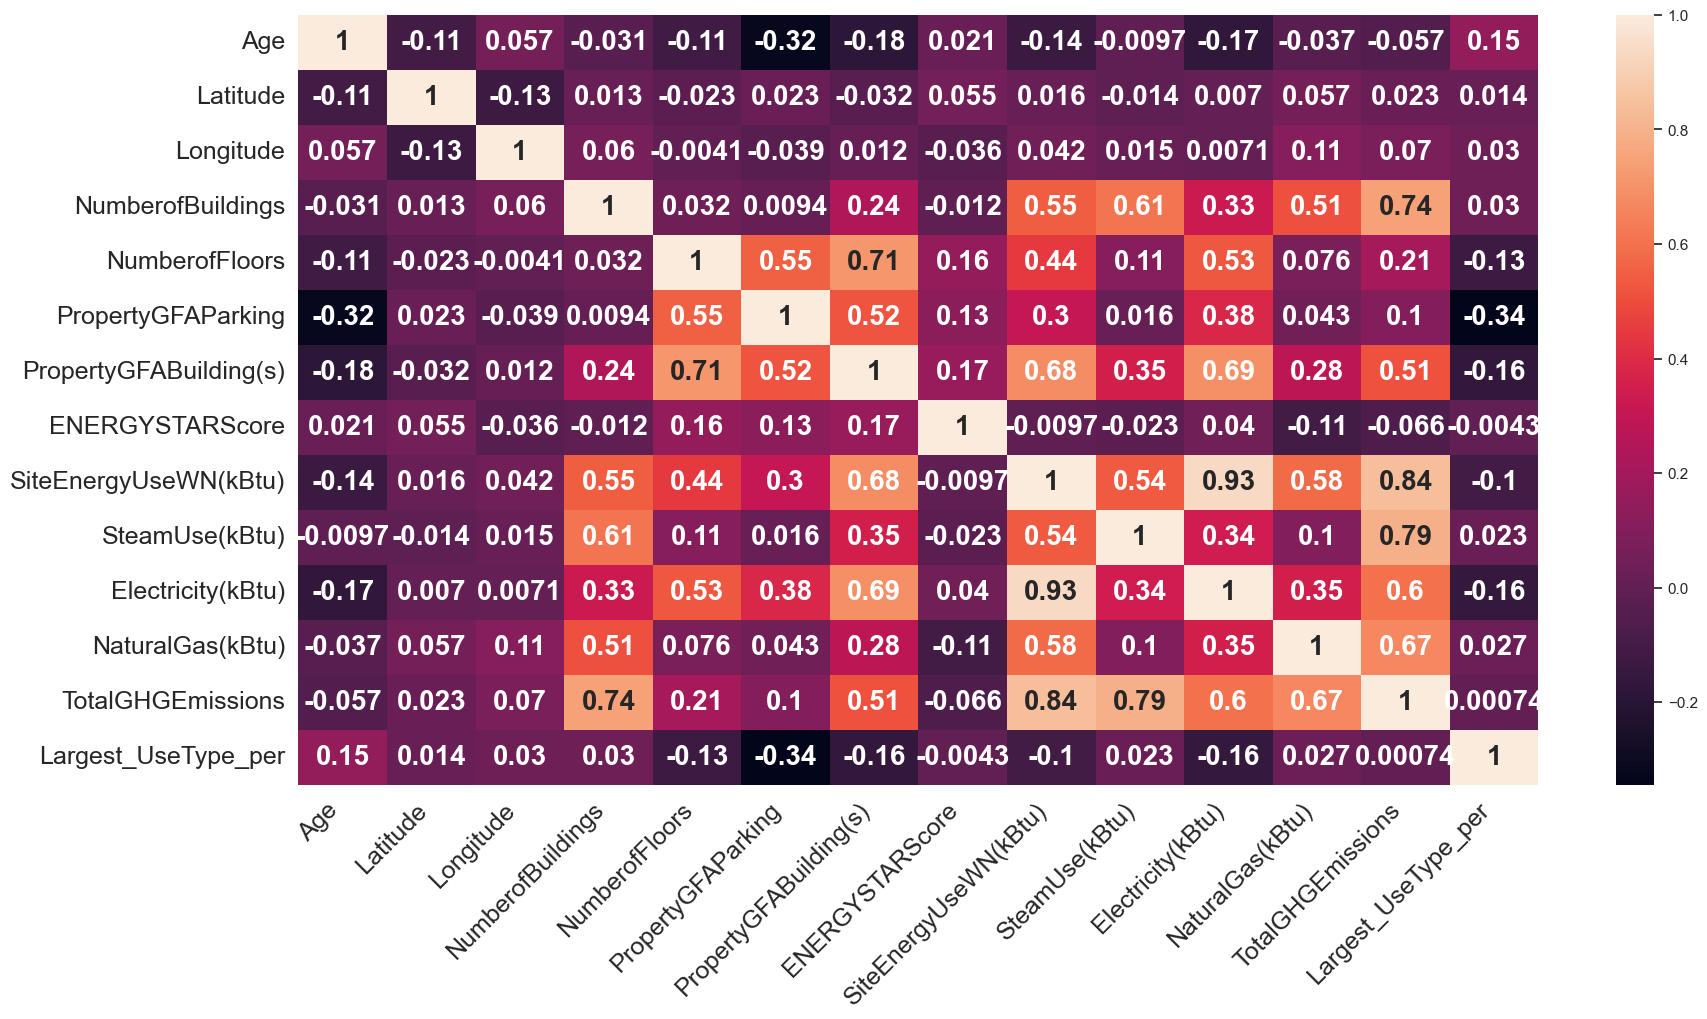

In [82]:
data_corr=data_2016.dropna().corr()
plt.figure(figsize=(20,10))
sns.heatmap(data_corr,annot=True,annot_kws={"size": 20,"fontweight":"bold"})
#plt.xlabel( "X-Axis Label",fontsize=24)
#plt.ylabel( fontsize=24)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=18)
plt.gca().set_yticklabels(plt.gca().get_yticklabels(), fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.show()

In [83]:
#Pour SteamUse(kBtu) et Electricity(kBtu) et NaturalGas(kBtu), il vaut mieux rajouter des colonnes binaires qui indiquent si oui ou non on utilise du Steam, Electrecity, Gas...

#et de plus, garder SteamUse(kBtu), Electricity(kBtu) et NaturalGas(kBtu) causerait un probleme de data-leakage car ces données sont directement corrélés à nos targets

# Encodage des variables catégorielles

In [84]:
list_Columns_categ = ['LargestPropertyUseType']

for columns in list_Columns_categ:
    data_2016 = pd.get_dummies(data_2016, columns=[columns])


In [85]:
data_2016.head()

,Age,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),...,LargestPropertyUseType_Office,LargestPropertyUseType_Other,LargestPropertyUseType_Parking,LargestPropertyUseType_Refrigerated Warehouse,LargestPropertyUseType_Residence Hall/Dormitory,LargestPropertyUseType_Retail Store,LargestPropertyUseType_Senior Care Community,LargestPropertyUseType_Supermarket/Grocery Store,LargestPropertyUseType_Wholesale Club/Supercenter,LargestPropertyUseType_Worship Facility
0,89,47.61220,-122.33799,1.0,12,0,88434,60.0,7456910.0,2003882.00,...,0,0,0,0,0,0,0,0,0,0
1,20,47.61317,-122.33393,1.0,11,15064,88502,61.0,8664479.0,0.00,...,0,0,0,0,0,0,0,0,0,0
2,47,47.61393,-122.33810,1.0,41,196718,759392,43.0,73937112.0,21566554.00,...,0,0,0,0,0,0,0,0,0,0
3,90,47.61412,-122.33664,1.0,10,0,61320,56.0,6946800.5,2214446.25,...,0,0,0,0,0,0,0,0,0,0
4,36,47.61375,-122.34047,1.0,18,62000,113580,75.0,14656503.0,0.00,...,0,0,0,0,0,0,0,0,0,0


In [86]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 3339
Data columns (total 35 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Age                                                           872 non-null    int64  
 1   Latitude                                                      872 non-null    float64
 2   Longitude                                                     872 non-null    float64
 3   NumberofBuildings                                             872 non-null    float64
 4   NumberofFloors                                                872 non-null    int64  
 5   PropertyGFAParking                                            872 non-null    int64  
 6   PropertyGFABuilding(s)                                        872 non-null    int64  
 7   ENERGYSTARScore                                               872 non-

# Création Colonnes binaires d'usage

In [87]:
#Pour SteamUse(kBtu) et Electricity(kBtu) et NaturalGas(kBtu), il vaut mieux rajouter des colonnes binaires qui indiquent si oui ou non on utilise du Steam, Electrecity, Gas...

#et de plus, garder SteamUse(kBtu), Electricity(kBtu) et NaturalGas(kBtu) causerait un probleme de data-leakage car ces données sont directement corrélés à nos targets

In [88]:
for value in data_2016['Electricity(kBtu)']:
    print(value)

3946027.0
3242851.0
49526664.0
2768924.0
5368607.0
2811215.0
7297919.0
6187627.0
1343000.0
13904183.0
3832369.0
21225277.0
5908370.0
24357833.0
2266231.0
5610706.0
2346349.0
3016399.0
1217589.0
4291585.0
1579749.0
2679739.0
9536160.0
5071973.0
4290059.0
45545529.0
3243900.0
1293561.0
2944680.0
3396109.0
3188457.0
4558937.0
551867.0
2423730.0
1978230.0
5679498.0
2812688.0
9886484.0
2660742.0
12871091.0
10980652.0
27597261.0
2944692.0
2637011.0
2128306.0
1337786.0
1887893.0
4897760.0
1398289.0
3926011.0
4402910.0
4197462.0
2316298.0
2657382.0
16224529.0
8653621.0
115641210.0
1859345.0
912475.0
1316817.0
8205020.0
4079217.0
5530787.0
2620548.0
1317637.0
6232233.0
2411402.0
423381.0
6138.0
3561742.0
2558533.0
975113.0
2338435.0
2496056.0
18745441.0
6322533.0
887532.0
3785282.0
9788716.0
4286102.0
18246151.0
37497068.0
40839637.0
27883939.0
1357845.0
6736076.0
3757005.0
8064399.0
26131643.0
6267781.0
39523847.0
17733276.0
3554872.0
4116601.0
17384553.0
10062435.0
44521844.0
24603417.0
37432

In [89]:
# Fonction conditionnelle pour créer les nouvelles colonnes
def create_usage_column(value):
    if value == 0:
        return 0
    else:
        return 1

# Création des nouvelles colonnes
data_2016['SteamUse(kBtu)_Usage'] = data_2016['SteamUse(kBtu)'].apply(create_usage_column)
data_2016['Electricity(kBtu)_Usage'] = data_2016['Electricity(kBtu)'].apply(create_usage_column)
data_2016['NaturalGas(kBtu)_Usage'] = data_2016['NaturalGas(kBtu)'].apply(create_usage_column)

In [90]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 3339
Data columns (total 38 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Age                                                           872 non-null    int64  
 1   Latitude                                                      872 non-null    float64
 2   Longitude                                                     872 non-null    float64
 3   NumberofBuildings                                             872 non-null    float64
 4   NumberofFloors                                                872 non-null    int64  
 5   PropertyGFAParking                                            872 non-null    int64  
 6   PropertyGFABuilding(s)                                        872 non-null    int64  
 7   ENERGYSTARScore                                               872 non-

In [91]:
for value in data_2016['Electricity(kBtu)_Usage'] :
    print(value)

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [92]:
# suppression des variables:SteamUse(kBtu) et Electricity(kBtu) et NaturalGas(kBtu)
data_2016 = data_2016.drop(["SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)"], axis=1)

In [93]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 3339
Data columns (total 35 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Age                                                           872 non-null    int64  
 1   Latitude                                                      872 non-null    float64
 2   Longitude                                                     872 non-null    float64
 3   NumberofBuildings                                             872 non-null    float64
 4   NumberofFloors                                                872 non-null    int64  
 5   PropertyGFAParking                                            872 non-null    int64  
 6   PropertyGFABuilding(s)                                        872 non-null    int64  
 7   ENERGYSTARScore                                               872 non-

In [94]:
data_2016['SiteEnergyUseWN(kBtu)'].value_counts()

7.456910e+06    1
2.596383e+06    1
2.629953e+05    1
1.745284e+06    1
6.656819e+05    1
               ..
1.633981e+07    1
4.395027e+06    1
9.336260e+06    1
2.257140e+07    1
4.731814e+06    1
Name: SiteEnergyUseWN(kBtu), Length: 872, dtype: int64

In [95]:
data_2016['TotalGHGEmissions'].value_counts()

6.30      3
39.47     2
8.85      2
38.21     2
8.80      2
         ..
23.48     1
35.56     1
116.95    1
111.69    1
134.80    1
Name: TotalGHGEmissions, Length: 851, dtype: int64

In [96]:
# Export des données formatées pour la modélisation
data_2016.to_csv("data_model.csv", sep=';',index=False)